<a href="https://colab.research.google.com/github/218r1a66b3/heart_disease-ml-/blob/main/heart_disease_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The main aim of the  Heart Disease project is to create a reliable system that can analyze a patient's medical data and accurately predict whether they are at risk of heart disease or not.**

In [1]:
# 1. Data Manipulation and Linear Algebra
import numpy as np
import pandas as pd

# 2. Data Visualization (To see patterns in Heart Disease)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Preprocessing (To prepare the data for the model)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 4. Machine Learning Model (The core algorithm)
from sklearn.linear_model import LogisticRegression

# 5. Evaluation Metrics (To see how well our aim was achieved)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

now data collection

In [39]:
#pd.read_csv(): This is a function from the Pandas library. It reads the .csv (Comma Separated Values) file and converts it into a DataFrame.
data=pd.read_csv('HEART DESEASE DATA.csv')

now printing the first 5 rows

In [3]:
#head function is used for priting the first 5 records
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


now printing last 5 rows

In [4]:
#tail function is used for
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
data.shape
#To understand the dimensions of our dataset.

(1025, 14)

In [6]:
data.info()
#To perform a technical audit of the dataset structure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


data.isnull().sum(): Essential to check for missing values. Machine learning models cannot perform math on empty cells; identifying them early prevents code crashes.


In [7]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [33]:
data["target"].value_counts()
#To determine if the dataset is Balanced or Imbalanced

,count
target,
1,526
0,499


/tmp/ipykernel_3231/1335705578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=data, palette='magma')


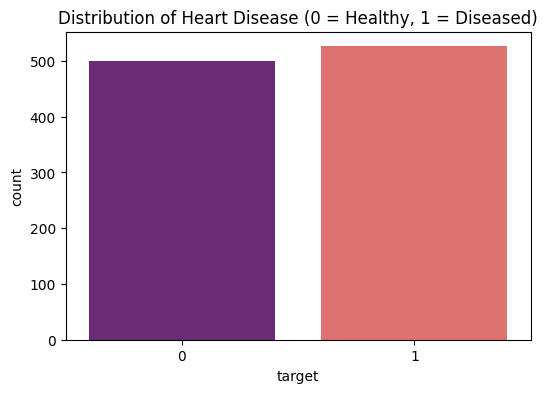

In [42]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data, palette='magma')
plt.title('Distribution of Heart Disease (0 = Healthy, 1 = Diseased)')
plt.show()
#To visualize the balance of our classes (Healthy vs. Diseased).

In [36]:
X=data.drop(columns='target',axis=1)
#X (Features): We drop the 'target' column so the model doesn't see the answers while it's studying.
y=data['target']
#y (Target): This contains only the result (1 or 0), which is what we want the model to learn to predict.

In [11]:
print(X)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

In [14]:
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


In [37]:
X_train,X_test, y_train,y_test=train_test_split(X,y, test_size=0.2,stratify=y,random_state=2)
#test_size=0.2: We use 80% of data for training and 20% for testing.


In [17]:
print(X.shape, X_train.shape, X_test.shape, y.shape, y_train.shape, y_test.shape)

(1025, 13) (820, 13) (205, 13) (1025,) (820,) (205,)


In [38]:
model=LogisticRegression()
#LogisticRegression: We chose this because it is excellent for Binary Classification (Yes/No outcomes).

In [20]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
X_train_prediction=model.predict(X_train)
accuracy = accuracy_score(X_train_prediction, y_train)
print(accuracy)

0.8524390243902439


We check Training Accuracy (85%) to see how well it learned.

In [27]:
X_test_prediction=model.predict(X_test)
accuracy = accuracy_score(X_test_prediction, y_test)
print(accuracy)

0.8048780487804879


We check Test Accuracy (80%) to see how it performs on new patients.



A small gap between these two numbers confirms the model is a Good Fit and not overfitted (memorizing).


In [30]:
input_data=(52,1,0,125,212,0,1,168,0,1,2,2,3)
input_data_asnumpy=np.asarray(input_data)
input_data_reshaped=input_data_asnumpy.reshape(1,-1)
#reshape(1, -1): Converts a single patient's list of data into the "Table" format the model expects.
prediction=model.predict(input_data_reshaped)
#model.predict(): The final step where the model uses everything it learned to give a diagnosis for a brand-new patient.
print(prediction)
if prediction==0:
  print("person does not have heart disease")
else:
  print("person has heart disease")


[0]
person does not have heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [31]:
input_data=(71,0,0,112,149,0,1,125,0,1.6,1,0,2)
input_data_asnumpy=np.asarray(input_data)
input_data_reshaped=input_data_asnumpy.reshape(1,-1)
#reshape(1, -1): Converts a single patient's list of data into the "Table" format the model expects.
prediction=model.predict(input_data_reshaped)
#model.predict(): The final step where the model uses everything it learned to give a diagnosis for a brand-new patient.
print(prediction)
if prediction==0:
  print("person does not have heart disease")
else:
  print("person has heart disease")


[1]
person has heart disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
